# 02 — Label Validation

**The Phase 1 gate.** Everything downstream inherits this label, and nothing downstream
rescues it. The question is not "is the label good" — it is *what exactly does it measure, and
what may I therefore claim*.

The label is the **blocked fraction over T → T+90**, per listing, from that listing's own
calendar. It is a **demand proxy**, never bookings: the Inside Airbnb calendar is
forward-looking availability, and blocked days include personal use, maintenance and seasonal
closure.

Four claims this notebook has to establish or retract:

1. The label is **discrete**, and its two endpoints are atoms rather than tails.
2. It correlates **positively** with independent demand signals in every city — weakly, and
   weakest on the signal the build guide nominated.
3. Most of that correlation runs through **listing establishment**, not demand. Within the
   established cohort, review *quality* orders it.
4. Those facts, not taste, decide how grades are cut.

Method notes that apply throughout: every per-city figure reads **Thessaloniki / Athens /
Crete**; nothing is ever pooled across cities (§2 shows why); and the label window is
July–September peak season, which is the strongest case for blocked ≈ booked.

## 0. The frame

One build, used by every section. `occupancy_label` owns **T**; `filters` owns row removal;
`reviews_in_window` takes T rather than re-deriving it, so a window used in validation is
computed exactly as the one used in training.

In [1]:
import numpy as np
import pandas as pd

from rental_ranking import eda
from rental_ranking.data.filters import filter_listings
from rental_ranking.data.paths import PROCESSED_DIR
from rental_ranking.features.label import crosscheck_availability_90, occupancy_label
from rental_ranking.features.reviews import reviews_in_window, same_season_last_year

pd.set_option("display.width", 120)

listings_df = pd.read_parquet(PROCESSED_DIR / "listings.parquet")
calendar_df = pd.read_parquet(PROCESSED_DIR / "calendar.parquet")
reviews_df = pd.read_parquet(PROCESSED_DIR / "reviews.parquet", columns=["listing_id", "date"])

labels = occupancy_label(calendar_df)
labelled = listings_df.merge(labels, left_on="id", right_index=True, how="inner")
ranked, filter_counts = filter_listings(labelled)

CITIES = ["thessaloniki", "athens", "crete"]
LABEL = "blocked_fraction_90"

print(f"{len(labelled):,} listings labelled  ->  {len(ranked):,} ranked")
filter_counts

46,635 listings labelled  ->  45,869 ranked


,n,inactive,long_term,both_rules,removed,kept
city,,,,,,
athens,14337,101,1,0,102,14235
crete,27333,523,43,1,565,26768
thessaloniki,4965,75,25,1,99,4866


The anchor is sound before anything is built on it: the calendar-derived availability
reproduces the `availability_90` column Inside Airbnb ships independently.

In [2]:
crosscheck_availability_90(labels, listings_df)

,n,exact_agreement,n_mismatched,mean_abs_diff
city,,,,
athens,14337,0.999861,2,0.009765
crete,27333,0.999744,7,0.006915
thessaloniki,4965,0.999597,2,0.031017


In [3]:
labels.head()

,T,calendar_days,calendar_span,avail_90,blocked_fraction_90
listing_id,,,,,
0000a41afda2,2026-06-30,365,365,44,0.511111
000127ae495c,2026-06-29,365,365,62,0.311111
000129366eef,2026-06-29,365,365,73,0.188889
00033436810a,2026-07-03,365,365,0,1.000000
0003c90ac65c,2026-06-29,365,365,43,0.522222


In [4]:
ranked.shape, labelled.shape

((45869, 63), (46635, 63))

In [5]:
filter_counts

,n,inactive,long_term,both_rules,removed,kept
city,,,,,,
athens,14337,101,1,0,102,14235
crete,27333,523,43,1,565,26768
thessaloniki,4965,75,25,1,99,4866


In [6]:
ranked.columns

Index(['id', 'name', 'host_id', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type',
       'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_checkout_date', 'minimum_nights', 'maximum_nights',
       'minimum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count', 'calculated_host_listing

## 1. What the label looks like

`blocked_fraction_90 = blocked_days / 90`, so it has exactly **91 attainable values**. A
histogram would bin across them and smear the endpoints into their neighbours — which is
precisely what needs looking at.

Terms used from here on:

- **Blocked day** — a calendar row with `available = False`. Not a booking.
- **Atom** — a point mass at exactly 0.0 or exactly 1.0, as opposed to the continuum between.
- **Interior** — every listing strictly between the two atoms.

In [7]:
def spike_table(frame: pd.DataFrame) -> pd.DataFrame:
    g = frame.groupby("city")["blocked_fraction_90"]
    return pd.DataFrame(
        {
            "n": g.size(),
            "at_0.0": g.apply(lambda s: s.eq(0).sum()),
            "at_0.0_%": (g.apply(lambda s: s.eq(0).mean()) * 100).round(2),
            "interior_%": (
                g.apply(lambda s: s.between(0, 1, inclusive="neither").mean()) * 100
            ).round(2),
            "at_1.0": g.apply(lambda s: s.eq(1).sum()),
            "at_1.0_%": (g.apply(lambda s: s.eq(1).mean()) * 100).round(2),
        }
    ).reindex(CITIES)


display(spike_table(labelled).style.set_caption("before filters"))
display(spike_table(ranked).style.set_caption("after filters"))

,n,at_0.0,at_0.0_%,interior_%,at_1.0,at_1.0_%
city,,,,,,
thessaloniki,4965,332,6.690000,85.680000,379,7.630000
athens,14337,683,4.760000,91.890000,480,3.350000
crete,27333,517,1.890000,90.320000,2130,7.790000


,n,at_0.0,at_0.0_%,interior_%,at_1.0,at_1.0_%
city,,,,,,
thessaloniki,4866,332,6.820000,87.030000,299,6.140000
athens,14235,682,4.790000,92.550000,379,2.660000
crete,26768,505,1.890000,92.160000,1593,5.950000


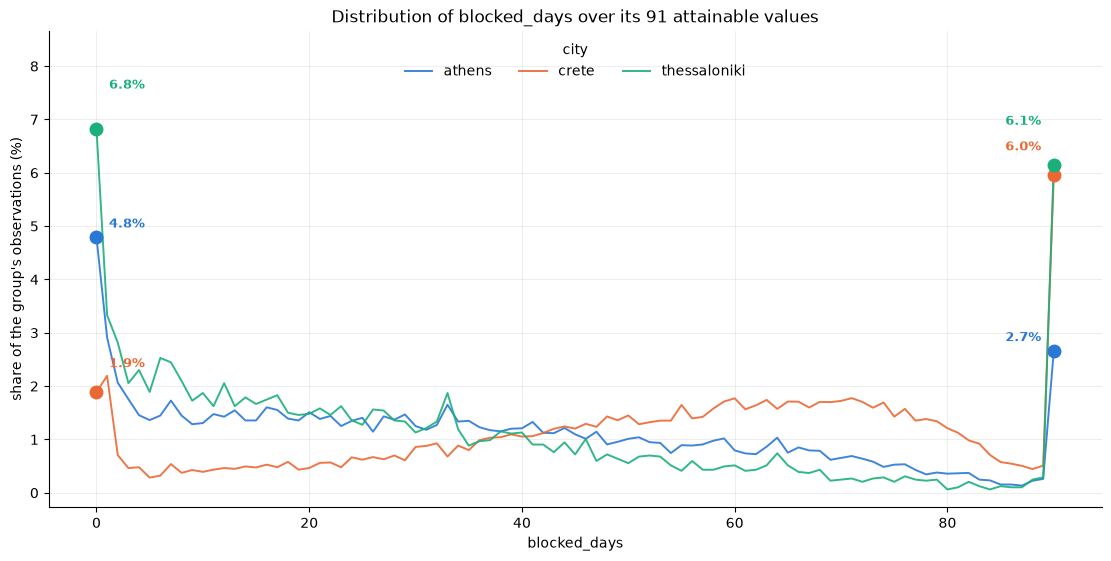

In [8]:
ranked["blocked_days"] = 90 - ranked["avail_90"]
eda.plot_discrete_distribution(ranked["blocked_days"], ranked["city"], highlight=(0, 90));

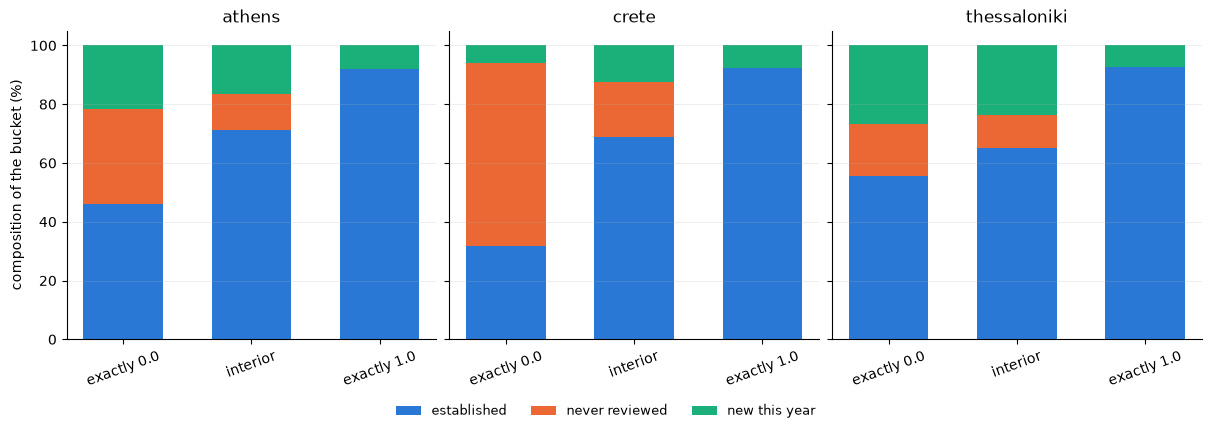

In [9]:
ranked["bucket"] = pd.cut(
    ranked["blocked_fraction_90"],
    [-0.01, 0.0001, 0.9999, 1.01],
    labels=["exactly 0.0", "interior", "exactly 1.0"],
)

age = ranked["T"] - ranked["first_review"]
ranked["cohort"] = np.where(
    ranked["first_review"].isna(),
    "never reviewed",
    np.where(age < pd.Timedelta(days=365), "new this year", "established"),
)

eda.plot_group_composition(ranked["bucket"], ranked["cohort"], ranked["city"]);

**TODO — read the two figures.** Expect the atoms to be different populations rather
than two ends of one distribution, and say which is which. Note what the filters already
removed and what they deliberately left behind.

## 2. Does it agree with independent demand signals?

The instrument is the **same season, one year earlier** — reviews in `[T−365, T−365+90)`,
anchored per listing. Entirely pre-T, so leakage-free, and seasonally matched to the label
window; a trailing window from T lands in May–June shoulder season and measures a different
demand regime.

Reviews and the calendar are genuinely separate source files, which is the independence that
matters here.

In [10]:
# The anchor is T from `labels`, indexed by listing_id. Never `ranked["T"]`: after the merge
# its index is positional, so nothing resolves and every count comes back 0.
ANCHORS = labels["T"]

ranked["ss_90"] = ranked["id"].map(same_season_last_year(reviews_df, ANCHORS, window_days=90))
ranked["trailing_90"] = ranked["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=90, starts_days_before=90)
)
ranked["trailing_30"] = ranked["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=30, starts_days_before=30)
)

DERIVED = ["ss_90", "trailing_90", "trailing_30"]
SHIPPED = [
    "number_of_reviews",
    "number_of_reviews_ly",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "estimated_occupancy_l365d",  # LABEL_ADJACENT: a caveated cross-check, never a feature
]

# This is what licenses every derived window below: our trailing-30 count has to reproduce a
# shipped column it never looked at. If this drifts, nothing else in the section is trustworthy.
ranked.groupby("city")[["trailing_30", "number_of_reviews_l30d"]].apply(
    lambda p: pd.Series(
        {
            "exact_match": p["trailing_30"].eq(p["number_of_reviews_l30d"]).mean(),
            "mean_abs_diff": (p["trailing_30"] - p["number_of_reviews_l30d"]).abs().mean(),
        }
    )
).reindex(CITIES).round(4)

,exact_match,mean_abs_diff
city,,
thessaloniki,0.9996,0.0004
athens,0.9973,0.0027
crete,0.9980,0.0020


In [11]:
from scipy.stats import spearmanr


def rho_by_city(frame: pd.DataFrame, signals: list[str], label: str = LABEL) -> pd.DataFrame:
    """Spearman per city, plus city-demeaned and pooled columns for contrast.

    Spearman rather than Pearson: the label is ordinal for our purposes and the review counts
    are heavily skewed, so a rank statistic is the honest one.
    """
    rows = {}
    for signal in signals:
        row = {
            city: spearmanr(part[signal], part[label], nan_policy="omit").statistic
            for city, part in frame.groupby("city")
        }
        demeaned_x = frame[signal] - frame.groupby("city")[signal].transform("mean")
        demeaned_y = frame[label] - frame.groupby("city")[label].transform("mean")
        row["city-demeaned"] = spearmanr(demeaned_x, demeaned_y, nan_policy="omit").statistic
        row["pooled"] = spearmanr(frame[signal], frame[label], nan_policy="omit").statistic
        rows[signal] = row
    return pd.DataFrame(rows).T[CITIES + ["city-demeaned", "pooled"]].round(3)


rho_by_city(ranked, DERIVED + SHIPPED)

,thessaloniki,athens,crete,city-demeaned,pooled
ss_90,0.124,0.225,0.194,0.197,0.164
trailing_90,0.061,0.194,0.215,0.182,0.059
trailing_30,0.087,0.199,0.178,0.165,0.093
number_of_reviews,0.179,0.279,0.291,0.246,0.175
number_of_reviews_ly,0.118,0.241,0.223,0.206,0.126
number_of_reviews_ltm,0.083,0.225,0.226,0.203,0.094
number_of_reviews_l30d,0.087,0.198,0.178,0.165,0.092
reviews_per_month,0.056,0.148,0.102,0.129,-0.080
estimated_occupancy_l365d,0.090,0.228,0.231,0.208,0.102


**Never pool across cities.** The pooled correlation sits *below* two of the three
cities, because the between-city gradient runs opposite to the within-city one — Crete is the
most blocked market *and* the thinnest-reviewed. Per-city is the correct statistic, not the
flattering one, and it is the same reason grades are cut within city.

In [12]:
# Same-season and trailing at matched widths, so season is the only thing that differs.
# At width 365 the two coincide by construction — [T-365, T-365+365) is [T-365, T) — so
# the last pair of rows being identical is the definition, not a bug.
WIDTHS = [30, 60, 90, 180, 365]

curve = {}
for width in WIDTHS:
    variants = {
        "trailing": reviews_in_window(
            reviews_df, ANCHORS, window_days=width, starts_days_before=width
        ),
        "same season ly": same_season_last_year(reviews_df, ANCHORS, window_days=width),
    }
    for kind, counts in variants.items():
        values = ranked["id"].map(counts)
        curve[(kind, width)] = {
            city: spearmanr(values.loc[part.index], part[LABEL]).statistic
            for city, part in ranked.groupby("city")
        }

pd.DataFrame(curve).T.rename_axis(["window", "days"])[CITIES].round(3)

,,thessaloniki,athens,crete
window,days,,,
trailing,30,0.087,0.199,0.178
same season ly,30,0.115,0.224,0.180
trailing,60,0.068,0.188,0.211
same season ly,60,0.120,0.235,0.180
trailing,90,0.061,0.194,0.215
same season ly,90,0.124,0.225,0.194
trailing,180,0.043,0.191,0.209
same season ly,180,0.098,0.229,0.206
trailing,365,0.083,0.225,0.226


In [13]:
labelled["ss_90"] = labelled["id"].map(same_season_last_year(reviews_df, ANCHORS))

before = rho_by_city(labelled, ["ss_90"] + SHIPPED)[CITIES]
after = rho_by_city(ranked, ["ss_90"] + SHIPPED)[CITIES]

pd.concat(
    {"before filters": before, "after filters": after, "change": (after - before).round(3)},
    axis=1,
)

before filters               after filters                     change              
                            thessaloniki athens  crete  thessaloniki athens  crete thessaloniki athens  crete
ss_90                              0.098  0.210  0.155         0.124  0.225  0.194        0.026  0.015  0.039
number_of_reviews                  0.138  0.257  0.236         0.179  0.279  0.291        0.041  0.022  0.055
number_of_reviews_ly               0.087  0.223  0.179         0.118  0.241  0.223        0.031  0.018  0.044
number_of_reviews_ltm              0.049  0.205  0.179         0.083  0.225  0.226        0.034  0.020  0.047
number_of_reviews_l30d             0.068  0.185  0.150         0.087  0.198  0.178        0.019  0.013  0.028
reviews_per_month                  0.058  0.148  0.102         0.056  0.148  0.102       -0.002  0.000  0.000
estimated_occupancy_l365d          0.056  0.208  0.185         0.090  0.228  0.231        0.034  0.020  0.046

**Report both.** The inactive filter removes exactly the (zero reviews, blocked = 1.0)
corner — the points that most depress a positive correlation — so filtering mechanically
raises rho. Publishing only the post-filter figure would be circular, and visibly so.

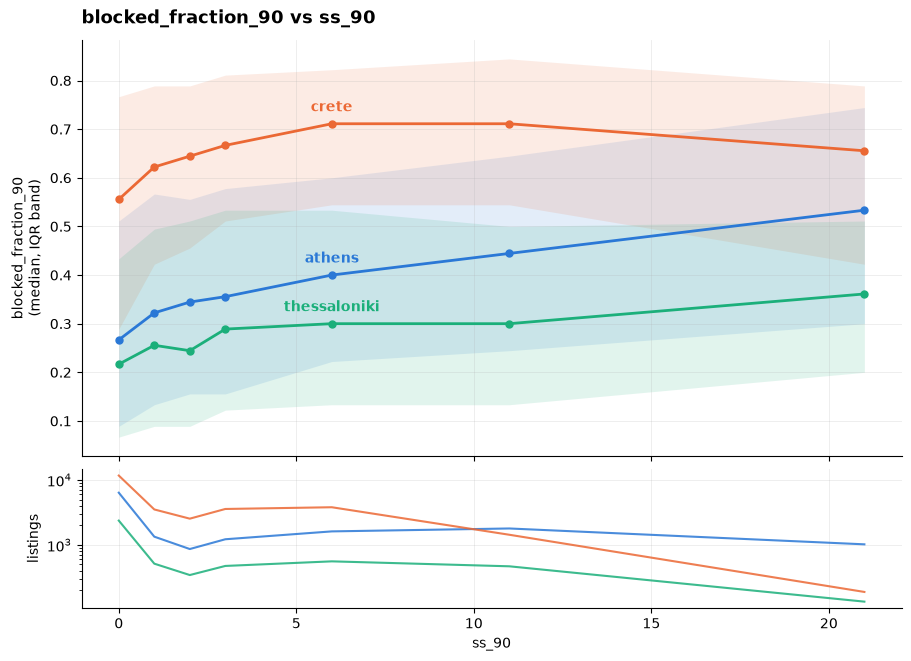

In [14]:
# Explicit count bins, not deciles: the signal is zero for ~45 % of listings, so quantile
# edges would collapse into each other and the first few bins would all be "0".
eda.plot_binned_relationship(
    ranked["ss_90"],
    ranked[LABEL],
    group=ranked["city"],
    bins=[-0.5, 0.5, 1.5, 2.5, 4.5, 8.5, 16.5, 500],
);

**TODO — the honest paragraph.** A monotone staircase argues better than a single rho,
and survives the ties that flatten a rank correlation. State the attenuation causes rather than
apologising for the number: blocked ≠ booked; a 90-day window correlated against lifetime or
trailing-year counts is a granularity mismatch; and the smallest, most off-season market has
the least to work with.

## 3. What the label actually encodes

The correlations in §2 are positive everywhere and weak everywhere. This section asks *where
they come from* — and the answer changes what may be claimed.

Cohorts are defined on `first_review` against T. That is the only listing-age proxy available:
`host_since` is 100 % null in all three cities.

In [15]:
# `cohort` was assigned in §1 from `first_review` against T. Sizes, before using it as a lens.
COHORTS = ["never reviewed", "new this year", "established"]

ranked.groupby(["city", "cohort"]).size().unstack("cohort")[COHORTS].reindex(CITIES)

cohort,never reviewed,new this year,established
city,,,
thessaloniki,533,1118,3215
athens,1837,2341,10057
crete,4934,3236,18598


In [16]:
ranked.pivot_table(index="city", columns="cohort", values=LABEL, aggfunc="mean")[COHORTS].reindex(
    CITIES
).round(3)

cohort,never reviewed,new this year,established
city,,,
thessaloniki,0.214,0.277,0.359
athens,0.243,0.323,0.416
crete,0.418,0.561,0.638


In [17]:
established = ranked[ranked["cohort"] == "established"].copy()

rho_by_city(established, DERIVED + SHIPPED)

,thessaloniki,athens,crete,city-demeaned,pooled
ss_90,0.034,0.151,0.065,0.109,0.033
trailing_90,-0.003,0.136,0.136,0.130,-0.019
trailing_30,0.053,0.146,0.112,0.116,0.032
number_of_reviews,0.084,0.172,0.128,0.148,0.004
number_of_reviews_ly,0.013,0.149,0.091,0.120,-0.036
number_of_reviews_ltm,-0.012,0.139,0.094,0.114,-0.035
number_of_reviews_l30d,0.053,0.146,0.111,0.116,0.032
reviews_per_month,0.051,0.153,0.117,0.128,-0.064
estimated_occupancy_l365d,-0.005,0.143,0.103,0.117,-0.023


**TODO — the decomposition.** If most of §2's correlation runs through establishment
rather than demand, say so here, in these words, before a reviewer says it for you. Note what
that implies for `reviews_per_month` — the one signal that normalises tenure away.

In [18]:
established["rating_band"] = established.groupby("city", observed=True)[
    "review_scores_rating"
].transform(lambda s: pd.qcut(s.rank(method="first"), 3, labels=["low", "mid", "high"]))

# A rating backed by six reviews is noise wearing a number. Gate, and show what the gate moves.
stable = established[established["number_of_reviews"] >= 10]

by_band = pd.concat(
    {
        "all established": established.pivot_table(
            index="city", columns="rating_band", values=LABEL, aggfunc="mean", observed=True
        ),
        ">= 10 reviews": stable.pivot_table(
            index="city", columns="rating_band", values=LABEL, aggfunc="mean", observed=True
        ),
        "median reviews (ungated)": established.pivot_table(
            index="city",
            columns="rating_band",
            values="number_of_reviews",
            aggfunc="median",
            observed=True,
        ),
    },
    axis=1,
).reindex(CITIES)

display(by_band.round(3))
display(
    ranked.pivot_table(index="city", columns="cohort", values=LABEL, aggfunc="mean")[
        ["never reviewed", "new this year"]
    ]
    .reindex(CITIES)
    .round(3)
)

all established               >= 10 reviews               median reviews (ungated)            
rating_band              low    mid   high           low    mid   high                      low   mid  high
city                                                                                                       
thessaloniki           0.287  0.368  0.423         0.275  0.371  0.442                     27.0  57.0  26.0
athens                 0.386  0.424  0.438         0.383  0.429  0.470                     28.0  72.0  33.0
crete                  0.586  0.680  0.648         0.606  0.686  0.693                     18.0  37.0   6.0

cohort,never reviewed,new this year
city,,
thessaloniki,0.214,0.277
athens,0.243,0.323
crete,0.418,0.561


In [19]:
pd.DataFrame(
    {
        "rating": {
            city: spearmanr(part["review_scores_rating"], part[LABEL], nan_policy="omit").statistic
            for city, part in stable.groupby("city")
        },
        "review volume": {
            city: spearmanr(part["number_of_reviews"], part[LABEL]).statistic
            for city, part in stable.groupby("city")
        },
        "n": stable.groupby("city").size(),
    }
).reindex(CITIES).round(3)

,rating,review volume,n
thessaloniki,0.255,0.081,2560
athens,0.136,0.175,7977
crete,0.177,0.096,12265


**TODO — the two-stage claim.** Establishment gets a listing into contention; review
quality orders it within that cohort. Write the claim you can defend and the one you cannot,
explicitly. Rating is also the *cleaner* instrument: review counts are mechanically produced by
the bookings the label measures, ratings are not.

## 4. What this means for grading

Grades are quantiles within `city × room_type × price tier`, and the scheme is decided:
**reserve the atoms, quantile the interior** — `0.0 → grade 0`, `1.0 → grade 4`, interior into
1–3. This section shows the evidence for that choice rather than asserting it.

Grading itself lives in `label.py` and runs after price imputation; this notebook only
establishes what the grading has to accommodate.

In [20]:
# The production partition is city x room_type x price tier, but price imputation is step 4
# and lives in features/price.py. Dropping the tier here moves nothing that matters: scheme B's
# end grades are the atoms, which are partition-independent, and scheme A is 20 % each by
# construction. Verified: cold-start burial 39.2 % here vs 40.6 % with the tier.
ranked["room_grp"] = np.where(
    ranked["room_type"].isin(["Entire home/apt", "Private room"]), ranked["room_type"], "Other"
)
PARTITION = ["city", "room_grp"]


def grade_pure_quantile(frame: pd.DataFrame) -> pd.Series:
    """Scheme A: five quantiles of the label within partition."""
    return frame.groupby(PARTITION, observed=True)[LABEL].transform(
        lambda s: pd.qcut(s.rank(method="first"), 5, labels=False, duplicates="drop")
    )


def grade_reserved_atoms(frame: pd.DataFrame) -> pd.Series:
    """Scheme B: 0.0 -> grade 0, 1.0 -> grade 4, the interior quantiled into 1-3."""
    grade = pd.Series(np.nan, index=frame.index)
    grade[frame[LABEL].eq(0.0)] = 0
    grade[frame[LABEL].eq(1.0)] = 4

    interior = frame[frame[LABEL].between(0, 1, inclusive="neither")]
    grade.loc[interior.index] = (
        interior.groupby(PARTITION, observed=True)[LABEL].transform(
            lambda s: pd.qcut(s.rank(method="first"), 3, labels=False, duplicates="drop")
        )
        + 1
    )
    return grade


ranked["grade_A"] = grade_pure_quantile(ranked)
ranked["grade_B"] = grade_reserved_atoms(ranked)

pd.concat(
    {
        "A pure quantile": ranked["grade_A"].value_counts(normalize=True).sort_index() * 100,
        "B reserved atoms": ranked["grade_B"].value_counts(normalize=True).sort_index() * 100,
    },
    axis=1,
).rename_axis("grade").round(1)

,A pure quantile,B reserved atoms
grade,,
0,20.0,3.3
1,20.0,30.6
2,20.0,30.6
3,20.0,30.6
4,20.0,5.0


In [21]:
def grade_mix(grade_column: str) -> pd.DataFrame:
    counts = ranked.pivot_table(
        index="cohort", columns=grade_column, values="id", aggfunc="size"
    ).reindex(COHORTS)
    return counts.div(counts.sum(axis=1), axis=0) * 100


pd.concat(
    {"A pure quantile": grade_mix("grade_A"), "B reserved atoms": grade_mix("grade_B")}, axis=1
).round(1)

A pure quantile                         B reserved atoms                       
grade_A                      0     1     2     3     4                0     1     2     3    4
cohort                                                                                        
never reviewed            39.2  21.7  16.8  13.7   8.6              8.1  47.0  25.8  19.1  NaN
new this year             22.9  23.3  21.2  18.2  14.4              4.0  35.4  32.3  25.7  2.6
established               15.0  18.9  20.5  21.8  23.8              2.1  25.8  31.3  34.2  6.6

**TODO — the fairness consequence.** Quantile grading assigns the bottom class to
cold-start listings at well above their base rate. Report the number under both schemes, and be
precise about what the chosen scheme does *not* fix — the ratio to base rate versus the
absolute count are different claims.

In [22]:
# The gradient sees query groups, not grading partitions. A group whose rows all share one
# grade contributes nothing to LambdaMART, so count them here rather than in Phase 3.
ranked["capacity_tier"] = pd.cut(
    ranked["accommodates"], [0, 2, 4, 6, 100], labels=["1-2", "3-4", "5-6", "7+"]
)
QUERY_GROUP = ["city", "neighbourhood_cleansed", "room_grp", "capacity_tier"]


def group_health(grade_column: str) -> pd.Series:
    graded = ranked.dropna(subset=[grade_column]).groupby(QUERY_GROUP, observed=True)[grade_column]
    sizes, distinct = graded.size(), graded.nunique()
    return pd.Series(
        {
            "groups": len(sizes),
            "singletons": int(sizes.eq(1).sum()),
            "zero-variance (size > 1)": int(((distinct == 1) & (sizes > 1)).sum()),
            "rows in usable groups": int(sizes[(sizes > 1) & (distinct > 1)].sum()),
            "mean distinct grades": distinct[sizes > 1].mean().round(2),
        }
    )


pd.DataFrame(
    {"A pure quantile": group_health("grade_A"), "B reserved atoms": group_health("grade_B")}
)

,A pure quantile,B reserved atoms
groups,517.00,517.00
singletons,64.00,64.00
zero-variance (size > 1),20.00,32.00
rows in usable groups,45750.00,45701.00
mean distinct grades,4.11,3.73


## 5. Limitations

State once, plainly, and do not re-apologise for them elsewhere.

- **Blocked ≠ booked.** A listing may be blocked for personal use, maintenance or seasonal
  closure. Nothing in this data separates those from demand.
- **The identification limit.** "Less blocked" reads two ways that cannot be told apart here:
  guests avoided it, or the host left it open *because* it does not sell. There are no
  bookings, no impressions and no price history. For ranking this does not matter; for a claim
  about demand it does.
- **Ratings are ceiling-compressed** — the 95th percentile is 5.0 in all three cities. Report
  bands and orderings only; a slope in rating units would imply a scale the data lacks.
- **Rating is undefined for never-reviewed listings**, so they and the rated cohort never sit
  on one axis.
- **One snapshot.** The temporal split is a guarantee about feature provenance, not a
  train/test split in time — there is no second period available.
- **Survivorship**, which cuts the other way: the worst listings delisted before the scrape, so
  measured gradients are attenuated rather than inflated.

## Verdict

**TODO.** State the gate outcome and the claim in one paragraph each — the claim being what
the label measures, in the narrowest form the evidence supports.

What Phase 2 inherits:

- the ranked population and its filter counts
- the label, its atoms, and the grading scheme those atoms imply
- the review-window machinery, which is a feature source as well as a validator
- listing age and rating reliability as things the model must be given *explicitly*, so the
  bias they carry can be measured rather than silently inherited

In [26]:
group_price_medians = (
    listings_df.groupby(
        ["city", "neighbourhood_cleansed", "room_type", "accommodates"],
        observed=True,
        dropna=False,
    )["price"]
    .agg(median_price="median", group_size="size")
    .reset_index()
)

group_price_medians.shape

(1140, 6)

In [27]:
group_price_medians

,city,neighbourhood_cleansed,room_type,accommodates,median_price,group_size
0,athens,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Entire home/apt,2,70.735,8
1,athens,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Entire home/apt,3,182.500,2
2,athens,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Entire home/apt,4,98.415,16
3,athens,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Entire home/apt,5,120.000,5
4,athens,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Entire home/apt,6,198.000,1
...,...,...,...,...,...,...
1135,thessaloniki,Thessaloniki,Private room,8,128.000,1
1136,thessaloniki,Thessaloniki,Private room,12,154.000,1
1137,thessaloniki,Thessaloniki,Shared room,1,NaN,1
1138,thessaloniki,Thessaloniki,Shared room,4,95.000,1
